## 🎯 Practice Exercises
## Exercise 1: Build Your First Stateful Agent

### Task
Create an agent with three custom tools:
1. **Weather tool:** Returns simulated weather for a given city
2. **Dictionary tool:** Looks up word definitions (simulate with a small dict)
3. **Web search tool:** Uses DuckDuckGo to search the web for information

### Requirements
1. Define tools using `@tool` decorator
2. Bind tools to LLM
3. Implement conditional routing (agent decides which tool to use)
4. Handle cases where no tool is needed
5. Install DuckDuckGo search: `pip install duckduckgo-search`
6. Use `DDGS().text()` method for web searches

### Example Queries
- "What's the weather in Lagos?" → Uses weather tool
- "Define the word 'ephemeral'" → Uses dictionary
- "Search for latest AI news" → Uses DuckDuckGo web search
- "What's the capital of France?" → No tool needed


## Step 1: Install Required Packages and Import Necessary Libraries

In [1]:
# install required packages
%pip install -q langchain langgraph langchain-openai python-dotenv requests duckduckgo-search

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import necessary libraries

from langgraph.graph import START, END, StateGraph, MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from IPython.display import Image, display
from typing import Literal, Annotated
from duckduckgo_search import DDGS
import requests
import os



print('All libraries successfully loaded')

c:\Users\Deborah Adelegan\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All libraries successfully loaded


## Step 2: Load API Key


In [3]:
# Load API Key

load_dotenv()
weather_api_key = os.getenv('weather_api_key')

if weather_api_key:
    print('API Key Successfully generated!')
else:
    print('API Key not found. Kindly load it correctly from your environment.')

# OPenWeatherMap API endpoint
base_url = "api.openweathermap.org/2.5/weather"


API Key Successfully generated!


## Step 3: Initialize the LLM

In [4]:
llm = ChatOpenAI(
    model= 'gpt-4o-mini',
    api_key = os.getenv('api_key'),
    temperature = 0
)

print('LLM Successfully Initialized:', llm.model_name)

LLM Successfully Initialized: gpt-4o-mini


## Step 4: Create the tools 

In [5]:
# Creating the weather tool
@tool
def weather(location: str) -> dict:
    """
    Provide current weather data in a particular location using OpenWeatherMap.
    Use this tool when you need to get weather data.
    
    Args:
        location : The city name or state (e.g. 'Lagos', 'Ibadan', 'Arinkanko')
    Returns a dictionary with structure:
        When successful:
            {
            "city": location,
            "temperature": temperature,
            "unit": "Celsius",
            "condition": description,
            "humidity": humidity,
            "source": "openweathermap",
            "confidence": "live"
            }
        Upon Failure:
                {
                "city": location,
                "error": "city_not_found"|"api_key_missing"|"network_error"|"api_error"|"timeout"|"invalid_response",
                "source": "openweathermap"}
    Examples: 
        weather information for lagos returns a dictionary with keys: city name, temperature, unit, condition, humidity, source and confidence
     
    Uncertainty:
        - Weather data is real-time but may be 10-30 minutes delayed
        - Temperature precision is ±0.5°C
    
    You must not assume:
            - Success means data is perfectly accurate
            - Errors are user-facing messages
    """

    base_url = "http://api.openweathermap.org/data/2.5/weather"
    # Set upParameters for API request
    params = {
        "q": location,              # City name
        "appid": weather_api_key,      # OpenWeatherMap API Key
        "units" : "metric"              # Get temperature in Celsius (use "imperial" for Fahrenheit)
    }
    
    # Make the API Request
    try:
        response = requests.get(base_url, params = params, timeout=10)
        response.raise_for_status()     # To raise an error for bad status codes

        # Parse the JSON Response
        data = response.json()

        # Extract the information
        temperature = data["main"]["temp"]
        description = data["weather"][0]["description"]
        humidity = data["main"]["humidity"]

        # Format the weather information
        weather_information = (
            f"city: {location.title()} "
            f"Temperature: {temperature}°C "
            f"Conditions: {description.title()} "
            f"Humidity: {humidity}% ",
            f"source: {Literal["openweathermap"]} ",
            f"confidence: {Literal['live']} "
       
        )
        return weather_information
    
    except requests.exceptions.HTTPError as e:
        if response.status_code == 404:
            return f"Error: City '{location}' not found. Please check the spelling."
        else:
            return f"Error fetching weather data: {str(e)}"
    except requests.exceptions.RequestException as e:
        return f"Error connecting to weather service: {str(e)}"
    except KeyError as e:
        return f"Error parsing weather data: {str(e)}"



print('Weather Fetching tool created successfully')


Weather Fetching tool created successfully


In [6]:
# Creating the Dictionary tool

@tool
def dictionary(word: str) -> dict:
    """
    Provide the meaning of a word in dictionary database
    Use this tool when you have to find the meaning of a word
    
    Args:
        word: The word to look up

    Returns dict with:
        {
        "status": "success",
        "word": lowered_word,
        "definition": dictionary_library[lowered_word],
        "source": "local_dictionary"
        } or 
        {
        "status": "error",
        "word": lowered_word,
        "error_code": "word_not_found"
        "source": "local_dictionary"
        }
        Error: {"status": "error", "word": str, : , "source": "local_dictionary"}
    
    Examples:
    Define "pragmatism" returns "an approach that evaluates theories or beliefs in terms of the success of their practical application. OR the quality of dealing with a problem in a sensible way that suits the conditions that really exist, rather than following fixed theories, ideas, or rule" 
    
    """

# Simulate the dictionary
    dictionary_library = {
            "ephemeral": "Lasting for a very short time; transient",
            "serendipity": "The occurrence of events by chance in a happy or beneficial way",
            "ubiquitous": "Present, appearing, or found everywhere",
            "nostalgia": "A sentimental longing for the past",
            "eloquent": "Fluent or persuasive in speaking or writing",
            "ambiguous": "Open to more than one interpretation; not clear",
            "benevolent": "Well-meaning and kindly",
            "catalyst": "A substance or person that precipitates an event or change",
            "diligent": "Having or showing care and conscientiousness",
            "pragmatic": "Dealing with things sensibly and realistically",
            "ubiquitous": "Present, appearing, or found everywhere",
            "nostalgia": "A sentimental longing for the past",
            "mellifluous": "Sweet or musical; pleasant to hear",
            "petrichor": "The pleasant, earthy smell after rain",
            "insouciant": "Showing a casual lack of concern; indifferent",
            "halcyon": "Denoting a period of time in the past that was idyllically happy and peaceful",
            "sonder": "The realization that each random passerby is living a life as vivid and complex as your own",
            "petrichor": "The pleasant, earthy smell after rain",
            "pulchritudinous": "Beautiful",
            "penumbra": "The partially shaded outer region of the shadow cast by an opaque object",
            "liminal": "Occupying a position at, or on both sides of, a boundary or threshold",
            "epiphany": "A moment of sudden and great revelation or realization",
            "ineffable": "Too great or extreme to be expressed or described in words"
}

    # Convert word into sall letters
    lowered_word = word.lower()


    if lowered_word in dictionary_library:
        return f" Definition of {word}: \n {dictionary_library[lowered_word]}"
    else: 
        return {
                "status": "error",
                "word": lowered_word,
                "error_code": "word_not_found",
                "source": "local_dictionary"
            }

In [7]:
# Creating the Websearch tool
@tool
def web_search(search_query: str) -> str:
    """
    Execute a web search query using DuckDuckGo 
    Use this tool when you are asked to search the web for an information
    
    Args:
        search_query: The search query
    
    Returns:
        str: A structured list of search results from DuckDuckGo, each containing a title, snippet, and source reference, limited to a fixed maximum number.
    
    """

    # Create the DuckDuckGoinstance
    try:
        ddgs = DDGS()
        # Perform the search and get the top 4 results
        results = ddgs.text(search_query, max_results=4)

        if not results:
            return f"No results found for {search_query}"
        
        # Set the format for the rsponse
        search_output = f"Search Results for '{search_query}':\n\n"

        for result in results:
            search_output += result['title']
            search_output += result['body']
            search_output += result['href']

        return search_output
    
    except Exception as e:
        return "Error performing web_search", e

## Step 5: Bind the tools to the LLM

In [8]:
# create a list of the tools
tools = [weather, dictionary, web_search]

# Bind the tools to the LLM
llm_with_tools = llm.bind_tools(tools)

print(f"LLM bound to {len(tools)} tools")
print(f"Tools: {[tool.name for tool in tools]}")

LLM bound to 3 tools
Tools: ['weather', 'dictionary', 'web_search']


## Step 6: Building the Agent Graph

#### **6.1: Define the Assistant Node**

In [9]:
# System prompt that encourages tool usage
sys_msg = SystemMessage(content=
"""You are a helpful assistant with access to tools.

When asked to provide current weather conditions for a specific location, use the weather tool.
When asked to define a specific word, use the dictionary tool.
When asked to get an information online, use the web_search tool

Only use tools when necessary - for simple questions, answer directly.""")

def assistant(state: MessagesState) -> dict:
    """
    The main agent node that processes user input and decides what to do.
    
    This function:
    1. Takes the current conversation state
    2. Passes messages to the LLM
    3. The LLM decides whether to use a tool or respond directly
    """

    messages = [sys_msg] + state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

print("Assistant Node Defined")

Assistant Node Defined


#### **6.2: Define Conditional Routing**

In [10]:
def should_continue(state: MessagesState) -> Literal["tools", "__end__"]:
    """
    Decide next step based on the last message
    
    If LLM calls a tool -> go to 'tools' node
    If LLM provides final answer -> go to END
    """
    
    # Get the last message in the conversation
    last_message = state['messages'][-1]

    # Confirm if the LLM makes tool calls
    if last_message.tool_calls:
        return "tools"
    # If there is no tool call, go to the end
    else:
        return "__end__"

print("Conditional routing function defined")

Conditional routing function defined


#### **6.3: Build the State Graph**

In [11]:
# Create the Graph
builder = StateGraph(MessagesState)

# Add nodes
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define the edges
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    should_continue,
    {"tools": "tools", "__end__": END}
)
builder.add_edge("tools", "assistant")

# Add Memory
memory = MemorySaver()
agent = builder.compile(checkpointer=memory)

print(" Agent graph compiled with tools and memory successfully")

 Agent graph compiled with tools and memory successfully


#### **6.4: Visualize the Graph**

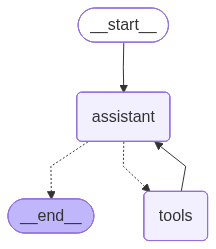

In [12]:
# Visualize the Agent Graph
try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not display graph: {e}")
    print("Graph structure: START → assistant → [conditional] → tools → assistant → END")


## Step 7: Test the Agent

In [13]:
# Helper Function
def run_assistant(user_input: str, thread_id: str = 'test_session'):
    """
    Run the agent and display the conversation.
    """
    print(f"\n{'='*100}")
    print(f'User: {user_input}')
    print(f"{'='*70}\n")


    result = agent.invoke(
        {"messages":[HumanMessage(content=user_input)]},
        config={"configurable": {"thread_id": thread_id}}
    )

    for msg in result["messages"]:
        if isinstance(msg, HumanMessage):
            continue
        elif isinstance(msg, AIMessage):
            if msg.tool_calls:
                print(f'Agent: [Calling tool: {msg.tool_calls[0]['name']}]')
            else: 
                print(f"Agent: {msg.content}")
        elif isinstance(msg, ToolMessage):
            print(f'Tool Result: {msg.content[:100]}...' if len(msg.content) > 100 else f"Tool Result: {msg.content}")


# Example Questions
# - "What's the weather in Lagos?"→ Uses weather tool
# - "Define the word 'ephemeral'" → Uses dictionary
# - "Search for latest AI news" → Uses DuckDuckGo web search
# - "What's the capital of France?" → No tool needed


## Step 8: Testing the Agents

### Test 1: Weather Tool

In [14]:
run_assistant('What is the weather in Lagos?')


User: What is the weather in Lagos?

Agent: [Calling tool: weather]
Tool Result: ["city: Lagos Temperature: 30.21°C Conditions: Clear Sky Humidity: 67% ", "source: typing.Literal['o...
Agent: The current weather in Lagos is as follows:
- **Temperature:** 30.21°C
- **Condition:** Clear Sky
- **Humidity:** 67% 

This information is sourced from OpenWeatherMap.


### Test 2: Dictionary Tool

In [15]:
run_assistant("Define the word 'ephemeral'")


User: Define the word 'ephemeral'

Agent: [Calling tool: weather]
Tool Result: ["city: Lagos Temperature: 30.21°C Conditions: Clear Sky Humidity: 67% ", "source: typing.Literal['o...
Agent: The current weather in Lagos is as follows:
- **Temperature:** 30.21°C
- **Condition:** Clear Sky
- **Humidity:** 67% 

This information is sourced from OpenWeatherMap.
Agent: [Calling tool: dictionary]
Tool Result:  Definition of ephemeral: 
 Lasting for a very short time; transient
Agent: The word "ephemeral" means lasting for a very short time; transient.


### Test 3: Web Search Tool

In [16]:
run_assistant("Search for latest AI news", "test")


User: Search for latest AI news



C:\Users\Deborah Adelegan\AppData\Local\Temp\ipykernel_17200\2108451871.py:18: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  ddgs = DDGS()


Agent: [Calling tool: web_search]
Tool Result: No results found for latest AI news
Agent: It seems that I couldn't find any recent news articles on AI at the moment. You might want to check popular news websites or technology blogs for the latest updates on artificial intelligence. If you have a specific topic in mind, let me know, and I can help you search for that!


### Test 4: No Tool Needed


In [17]:
run_assistant("Hello! What can you help me with?")


User: Hello! What can you help me with?

Agent: [Calling tool: weather]
Tool Result: ["city: Lagos Temperature: 30.21°C Conditions: Clear Sky Humidity: 67% ", "source: typing.Literal['o...
Agent: The current weather in Lagos is as follows:
- **Temperature:** 30.21°C
- **Condition:** Clear Sky
- **Humidity:** 67% 

This information is sourced from OpenWeatherMap.
Agent: [Calling tool: dictionary]
Tool Result:  Definition of ephemeral: 
 Lasting for a very short time; transient
Agent: The word "ephemeral" means lasting for a very short time; transient.
Agent: Hello! I can assist you with a variety of tasks, including:

1. **Weather Information:** Provide current weather conditions for specific locations.
2. **Word Definitions:** Look up and define words for you.
3. **Web Searches:** Find information online based on your queries.

Feel free to ask me anything within these areas or let me know if you have other questions!


In [18]:
run_assistant("What's the capital of France?")


User: What's the capital of France?

Agent: [Calling tool: weather]
Tool Result: ["city: Lagos Temperature: 30.21°C Conditions: Clear Sky Humidity: 67% ", "source: typing.Literal['o...
Agent: The current weather in Lagos is as follows:
- **Temperature:** 30.21°C
- **Condition:** Clear Sky
- **Humidity:** 67% 

This information is sourced from OpenWeatherMap.
Agent: [Calling tool: dictionary]
Tool Result:  Definition of ephemeral: 
 Lasting for a very short time; transient
Agent: The word "ephemeral" means lasting for a very short time; transient.
Agent: Hello! I can assist you with a variety of tasks, including:

1. **Weather Information:** Provide current weather conditions for specific locations.
2. **Word Definitions:** Look up and define words for you.
3. **Web Searches:** Find information online based on your queries.

Feel free to ask me anything within these areas or let me know if you have other questions!
Agent: The capital of France is Paris.
